<a href="https://colab.research.google.com/github/alubillijyaneswarrao-creator/Titanic-Survival-Predict/blob/main/Titanic_Survival_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score
)

import joblib

In [3]:
df = pd.read_csv(
    "cleaned_titanic.csv"
)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir,AgeGroup_Adult,AgeGroup_Child,AgeGroup_Senior,AgeGroup_Teen
0,1,0,3,"Braund, Mr. Owen Harris",1,-0.565736,1,0,A/5 21171,-0.502445,...,False,True,False,False,False,False,True,False,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,0.663861,1,0,PC 17599,0.786845,...,False,False,True,False,False,False,True,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,-0.258337,0,0,STON/O2. 3101282,-0.488854,...,False,False,False,False,False,False,True,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,0.433312,1,0,113803,0.420730,...,False,False,True,False,False,False,True,False,False,False
4,5,0,3,"Allen, Mr. William Henry",1,0.433312,0,0,373450,-0.486337,...,False,True,False,False,False,False,True,False,False,False


In [4]:
print(df.shape)

df.info()

(891, 36)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 36 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      891 non-null    int64  
 1   Survived         891 non-null    int64  
 2   Pclass           891 non-null    int64  
 3   Name             891 non-null    object 
 4   Sex              891 non-null    int64  
 5   Age              891 non-null    float64
 6   SibSp            891 non-null    int64  
 7   Parch            891 non-null    int64  
 8   Ticket           891 non-null    object 
 9   Fare             891 non-null    float64
 10  Cabin            891 non-null    object 
 11  FamilySize       891 non-null    float64
 12  Embarked_C       891 non-null    bool   
 13  Embarked_Q       891 non-null    bool   
 14  Embarked_S       891 non-null    bool   
 15  Title_Capt       891 non-null    bool   
 16  Title_Col        891 non-null    bool   
 17  Title_

In [5]:
X = df.drop(
    "Survived",
    axis=1
)

y = df["Survived"]

X = X.select_dtypes(
    include=[
        "int64",
        "float64",
        "bool"
    ]
)

In [6]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)

In [7]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

print(
    "Linear Regression Model Trained"
)

Linear Regression Model Trained


In [8]:
tree_model = (
    DecisionTreeClassifier(
        random_state=42
    )
)

tree_model.fit(
    X_train,
    y_train
)

print(
    "Decision Tree Model Trained"
)

Decision Tree Model Trained


In [9]:
linear_predictions = (
    linear_model.predict(
        X_test
    )
)

tree_predictions = (
    tree_model.predict(
        X_test
    )
)

In [10]:
mse = mean_squared_error(
    y_test,
    linear_predictions
)

r2 = r2_score(
    y_test,
    linear_predictions
)

print(
    "MSE:",
    mse
)

print(
    "R2 Score:",
    r2
)

MSE: 0.1370757329987393
R2 Score: 0.43474342844110603


In [11]:
accuracy = accuracy_score(
    y_test,
    tree_predictions
)

print(
    "Decision Tree Accuracy:",
    accuracy
)

Decision Tree Accuracy: 0.7597765363128491


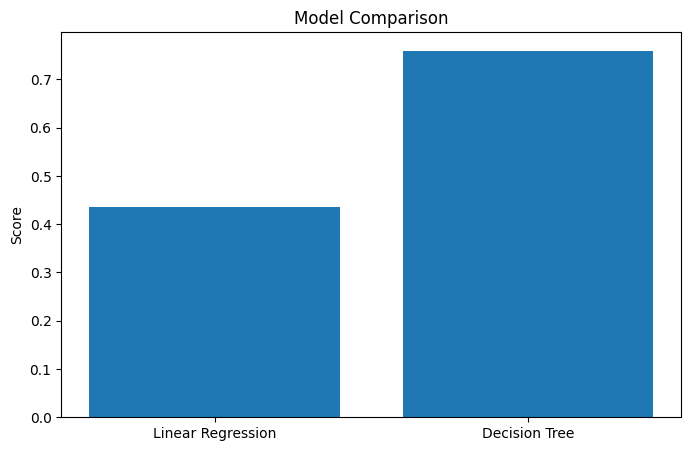

In [12]:
models = [
    "Linear Regression",
    "Decision Tree"
]

scores = [
    r2,
    accuracy
]

plt.figure(
    figsize=(8,5)
)

plt.bar(
    models,
    scores
)

plt.title(
    "Model Comparison"
)

plt.ylabel(
    "Score"
)

plt.show()

In [13]:
joblib.dump(
    linear_model,
    "linear_regression_model.pkl"
)

joblib.dump(
    tree_model,
    "decision_tree_model.pkl"
)

print(
    "Models Saved Successfully"
)

Models Saved Successfully


In [14]:
print("\nProject Completed Successfully")


Project Completed Successfully
